# 第 20 章评估实验
公开汽车与 Iris 沿用前章。垃圾信息概率、类别不平衡与泄漏实验为原创教学设定。历史测试部分仅作复核。

In [1]:
from examples.evaluation_core import evaluate_existing, threshold_report, binary_report, leakage_experiment
import pandas as pd
rows,manifest=evaluate_existing()
print(pd.DataFrame(rows).to_string(index=False))

          task       model   metric  train_score     cv_mean      cv_std  historical_test_score
classification    baseline accuracy     0.333333    0.333333    0.000000               0.333333
classification    logistic accuracy     0.958333    0.958333    0.045644               0.933333
classification tree_depth1 accuracy     0.666667    0.666667    0.000000               0.666667
classification   tree_full accuracy     1.000000    0.941667    0.033333               0.933333
    regression    baseline      MAE  5023.323286 5025.547241 1050.645813            8316.000000
    regression      single      MAE  2532.002580 2549.737564  133.790560            4107.632143
    regression       multi      MAE  2111.837112 2182.796616  183.522736            3615.895256


In [2]:
first=manifest["iris_logistic"]
print("外层训练/测试",len(first["outer_train_ids"]),len(first["outer_test_ids"]))
for fold in first["folds"]:
    print(fold["fold"],len(fold["train_positions"]),len(fold["validation_positions"]),fold["score"])

外层训练/测试 120 30
1 96 24 1.0
2 96 24 0.9583333333333334
3 96 24 0.875
4 96 24 0.9583333333333334
5 96 24 1.0


In [3]:
print(pd.DataFrame([threshold_report(.5),threshold_report(.25)]).to_string(index=False))

 threshold  TN  FP  FN  TP  accuracy  precision  recall       F1
      0.50   5   1   2   2       0.7   0.666667    0.50 0.571429
      0.25   3   3   1   3       0.6   0.500000    0.75 0.600000


In [4]:
print(binary_report([0]*95+[1]*5,[0]*100))

{'TN': 95, 'FP': 0, 'FN': 5, 'TP': 0, 'accuracy': 0.95, 'precision': 0.0, 'recall': 0.0, 'F1': 0.0}


In [5]:
leak=leakage_experiment()
print({k:v for k,v in leak.items() if not isinstance(v,list)})

{'source': '原创随机噪声教学实验', 'seed': 7, 'train_rows': 300, 'test_rows': 100, 'clean_train_accuracy': 1.0, 'clean_test_accuracy': 0.52, 'leaked_train_accuracy': 1.0, 'leaked_test_accuracy': 1.0, 'clean_features': 6, 'leaked_features': 7}


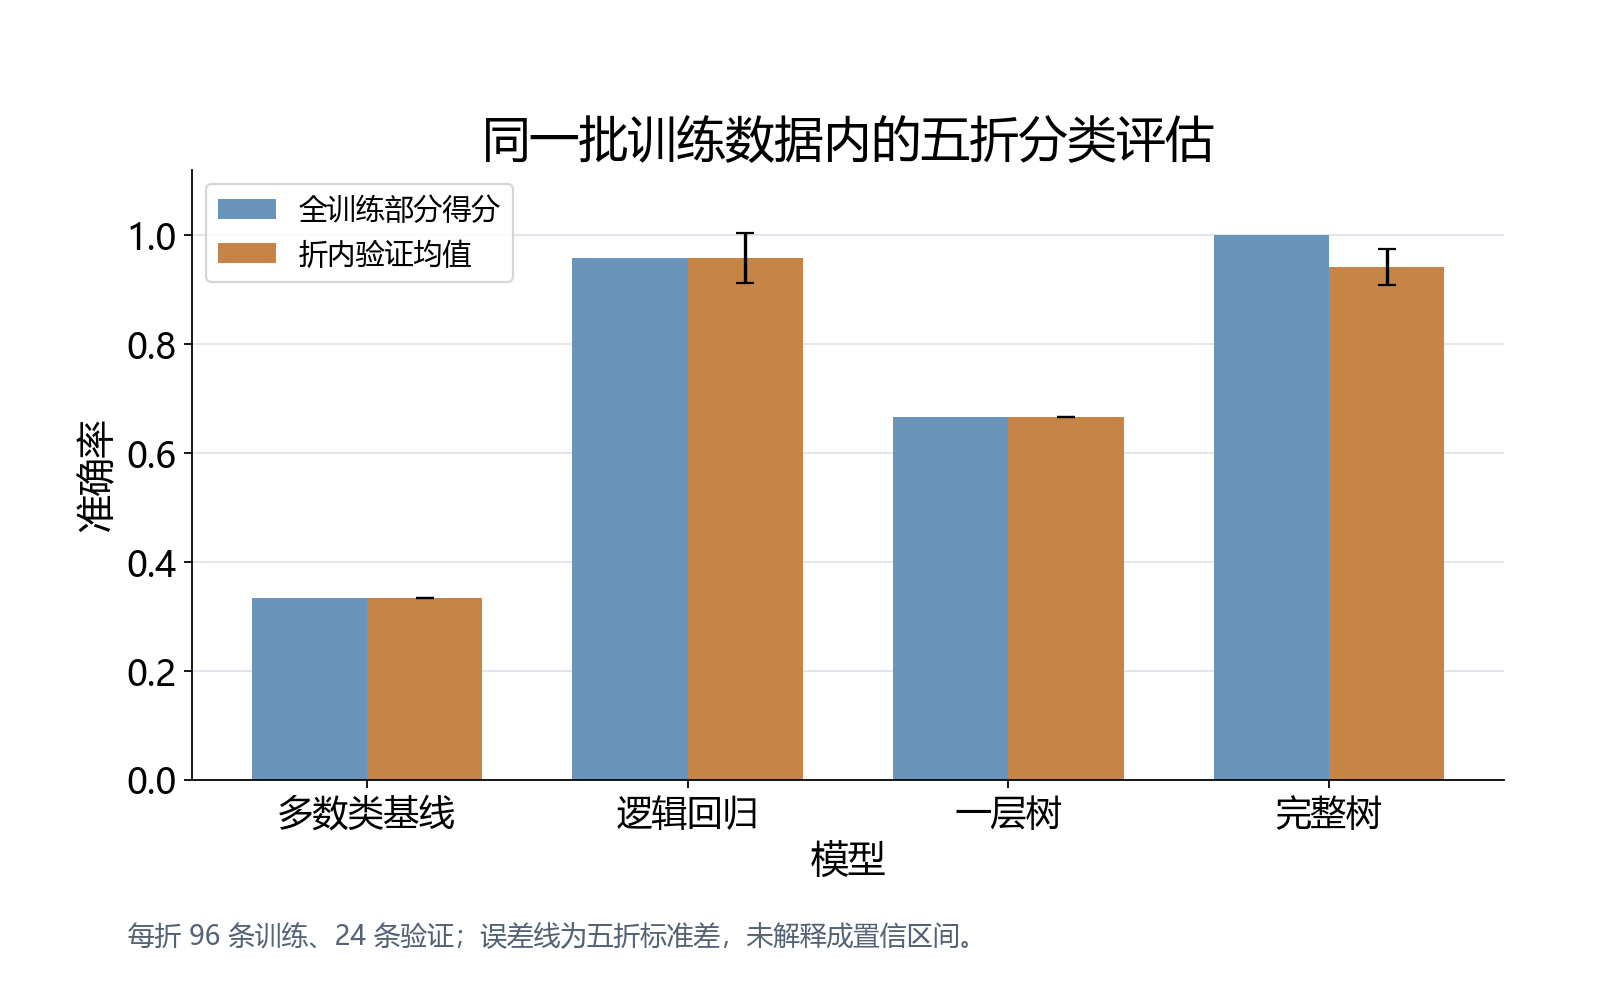

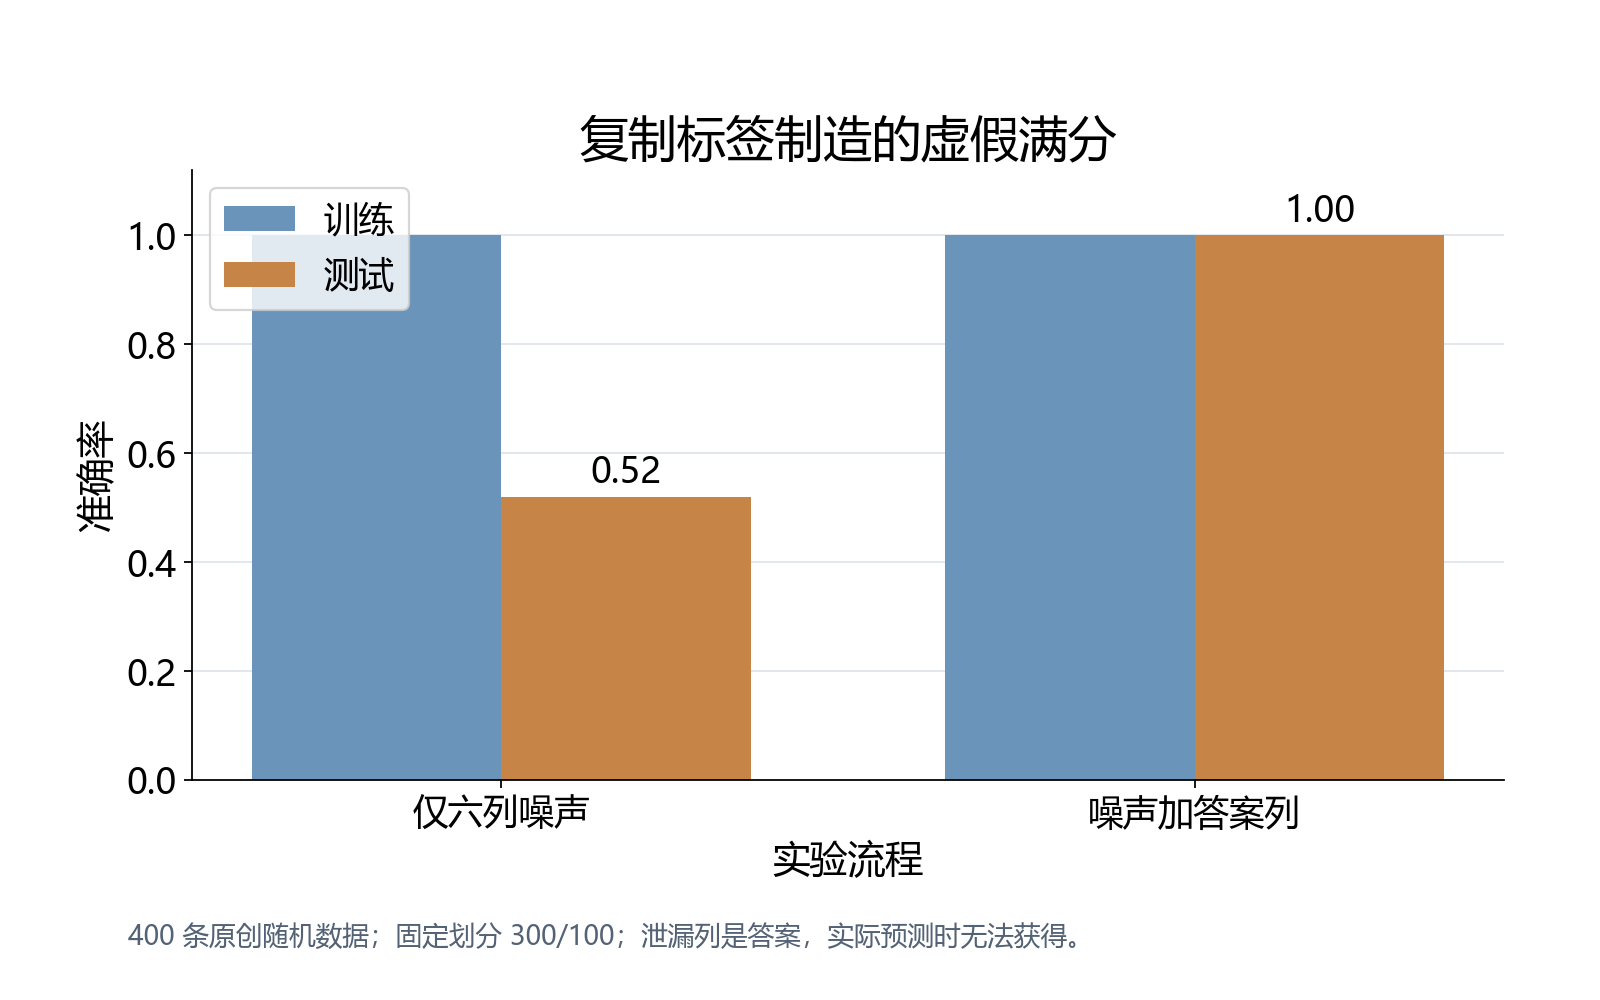

In [6]:
from IPython.display import display,Image
for name in ["overfitting-comparison","leakage-demo"]:
    display(Image(filename=f"assets/{name}.png",width=700))

In [7]:
report=binary_report([1,1,1,0,0],[1,0,1,1,0])
print(report)
assert report["TP"]==2 and report["FP"]==1 and report["FN"]==1

{'TN': 1, 'FP': 1, 'FN': 1, 'TP': 2, 'accuracy': 0.6, 'precision': 0.6666666666666666, 'recall': 0.6666666666666666, 'F1': 0.6666666666666666}
